# Module 4 — Class 1: Linear Regression + Gradient Descent

**Level 1 — Beginner / Lite / Classroom Companion — FLOW UPDATED**

This notebook follows the new live flow:

1. intro;
2. **one early Colab preparation block**: load → inspect → split;
3. modeling and interpretation without setup interruptions.

It is more technical than Level 0, but still follows the same lesson order.


## Slides 1–2 — Topic + Route

**What Darya explains:**
- We move from prepared data to the first supervised model.
- Regression predicts numeric values.
- Today’s full route: prepare data → model → evaluate → interpret → improve.

**What you do:**
Run setup and prepare for the live workflow.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✅ Setup complete")

✅ Setup complete


## Slide 3 — Colab Preparation Dashboard

This block combines the old separate setup slides:

1. **Load Superstore**
2. **Look before modeling**
3. **Train/test split**

**Your quick task:** after running this block, identify target, features, train rows, and test rows.


In [17]:
# Robust Superstore dataset loader
# Loading modes:
# 1) preferred: local/pre-uploaded files in Colab
# 2) manual_upload: upload CSV manually
# 3) external_source: public GitHub fallback, then optional KaggleHub fallback

import os
import glob
import pandas as pd
import numpy as np

LOADING_MODE = "preferred"  # change to: "manual_upload" or "external_source"

COMMON_FILENAMES = [
    "superstore_cleaned.csv",
    "SampleSuperstore.csv",
    "Sample - Superstore.csv",
    "Superstore.csv",
    "superstore.csv",
]

COMMON_ENCODINGS = ["utf-8", "latin1", "windows-1252", "ISO-8859-1"]

def read_csv_safely(path_or_url):
    """Try common encodings and return a DataFrame."""
    last_error = None
    for enc in COMMON_ENCODINGS:
        try:
            return pd.read_csv(path_or_url, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error

def find_local_superstore_file():
    """Find a likely Superstore CSV in the current Colab folder."""
    for name in COMMON_FILENAMES:
        if os.path.exists(name):
            return name
    csv_files = glob.glob("*.csv")
    for file in csv_files:
        lower = file.lower()
        if "superstore" in lower or "store" in lower or "sales" in lower:
            return file
    return None

def load_superstore(mode="preferred"):
    """Load Superstore data using preferred, manual_upload, or external_source mode."""
    if mode == "preferred":
        local_file = find_local_superstore_file()
        if local_file:
            print(f"✅ Found local file: {local_file}")
            return read_csv_safely(local_file)
        print("⚠️ No local Superstore CSV found. Trying external source...")
        mode = "external_source"

    if mode == "manual_upload":
        try:
            from google.colab import files
            uploaded = files.upload()
            if not uploaded:
                raise ValueError("No file was uploaded.")
            file_name = list(uploaded.keys())[0]
            print(f"✅ Uploaded file: {file_name}")
            return read_csv_safely(file_name)
        except Exception as e:
            raise RuntimeError(
                "Manual upload failed. Please upload a Superstore CSV file, "
                "for example 'Sample - Superstore.csv'. Original error: " + str(e)
            )

    if mode == "external_source":
        urls = [
            "https://raw.githubusercontent.com/datasciencedojo/datasets/master/Superstore.csv",
        ]
        for url in urls:
            try:
                print(f"🌐 Trying public source: {url}")
                return read_csv_safely(url)
            except Exception as e:
                print("Could not load from this URL:", e)
        try:
            import kagglehub
            path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
            csv_candidates = glob.glob(os.path.join(path, "*.csv"))
            if not csv_candidates:
                raise FileNotFoundError("KaggleHub downloaded the dataset, but no CSV file was found.")
            print(f"✅ KaggleHub file: {csv_candidates[0]}")
            return read_csv_safely(csv_candidates[0])
        except Exception as e:
            raise RuntimeError(
                "Could not load Superstore from local files, manual upload, or external sources.\n"
                "Try uploading 'Sample - Superstore.csv' manually.\n"
                "Original error: " + str(e)
            )

    raise ValueError("LOADING_MODE must be 'preferred', 'manual_upload', or 'external_source'.")

# Load data
df = load_superstore(LOADING_MODE)

# Normalize common column names lightly: strip spaces only, do not rename business columns.
df.columns = [str(c).strip() for c in df.columns]

print("✅ Data loaded!")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

def find_column(possible_names):
    lower_map = {c.lower().replace(" ", "").replace("_", ""): c for c in df.columns}
    for name in possible_names:
        key = name.lower().replace(" ", "").replace("_", "")
        if key in lower_map:
            return lower_map[key]
    return None

TARGET_COL = find_column(["Sales"])
PROFIT_COL = find_column(["Profit"])
QUANTITY_COL = find_column(["Quantity"])
DISCOUNT_COL = find_column(["Discount"])

KEY_NUMERIC_COLS = [c for c in [TARGET_COL, QUANTITY_COL, DISCOUNT_COL, PROFIT_COL] if c is not None]

if TARGET_COL is None:
    raise ValueError("❌ Could not find the target column 'Sales'. Please check your dataset columns.")

print("🎯 Target column:", TARGET_COL)
print("🔢 Key numeric columns found:", KEY_NUMERIC_COLS)

df.head()

⚠️ No local Superstore CSV found. Trying external source...
🌐 Trying public source: https://raw.githubusercontent.com/datasciencedojo/datasets/master/Superstore.csv
Could not load from this URL: HTTP Error 404: Not Found
Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
✅ KaggleHub file: /kaggle/input/superstore-dataset-final/Sample - Superstore.csv
✅ Data loaded!
Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
🎯 Target column: Sales
🔢 Key numeric columns found: ['Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Numeric columns for this lesson: ['Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Sales       0
Quantity    0
Discount    0
Profit      0
dtype: int64


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


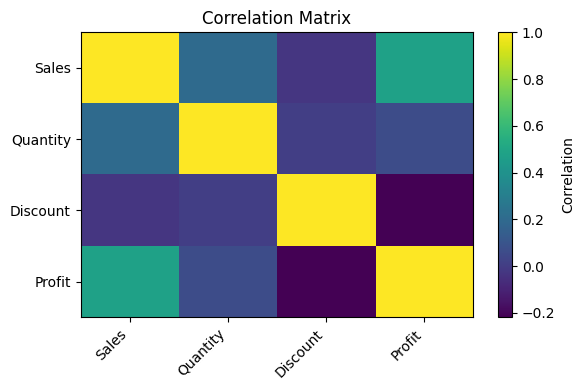

In [3]:
numeric_cols = [c for c in [TARGET_COL, QUANTITY_COL, DISCOUNT_COL, PROFIT_COL] if c is not None]

print("Numeric columns for this lesson:", numeric_cols)

print("\nMissing values:")
print(df[numeric_cols].isna().sum())

display(df[numeric_cols].describe())

corr = df[numeric_cols].corr(numeric_only=True)
display(corr)

plt.figure(figsize=(6, 4))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [4]:
# Prepare X/y and train/test split early.
# We create it now so the notebook is ready for the live modeling flow.

features = [c for c in [DISCOUNT_COL, QUANTITY_COL, PROFIT_COL] if c is not None]
X = df[features].copy()
y = df[TARGET_COL].copy()

# Keep only rows without missing values in selected columns.
model_data = pd.concat([X, y], axis=1).dropna()
X = model_data[features]
y = model_data[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Colab preparation complete!")
print("Target:", TARGET_COL)
print("Features:", features)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


✅ Colab preparation complete!
Target: Sales
Features: ['Discount', 'Quantity', 'Profit']
Training rows: 7995
Testing rows: 1999


## Slides 4–6 — Business Problem, Regression, Features/Target

**Core idea:**
- Target = `Sales`.
- Features = input clues.
- Regression predicts a number.

**Think about it:** Why is `Sales` not a classification target?


## Slide 7 — First Visual Pattern

**What we do now:**
- Plot `Discount` vs `Sales`.
- Notice that real data is noisy.


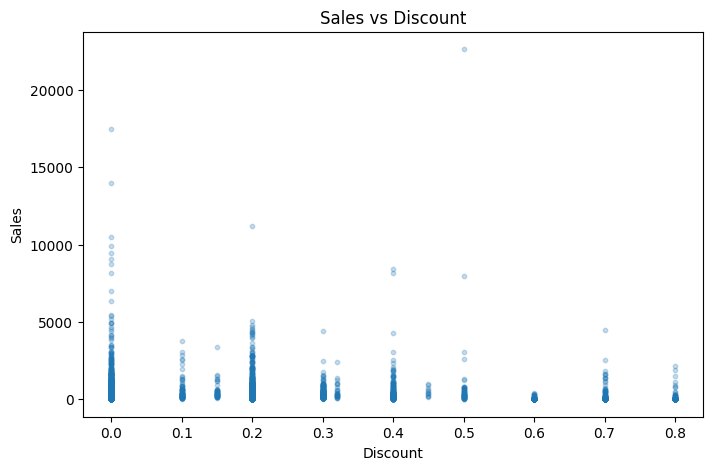

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df[DISCOUNT_COL], df[TARGET_COL], alpha=0.25, s=10)
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.title('Sales vs Discount')
plt.show()


## Slide 8 — OLS vs Gradient Descent

`LinearRegression()` usually solves the best coefficients directly with **Ordinary Least Squares (OLS)**.

Later, the **Gradient Descent** demo shows a step-by-step optimization method used by many other ML models.


## Slide 9 — Simple Linear Regression: Sales ~ Discount

**What we do now:**
- Train a one-feature baseline.
- Read coefficient and intercept.

**Quick task:** write one sentence explaining the coefficient.


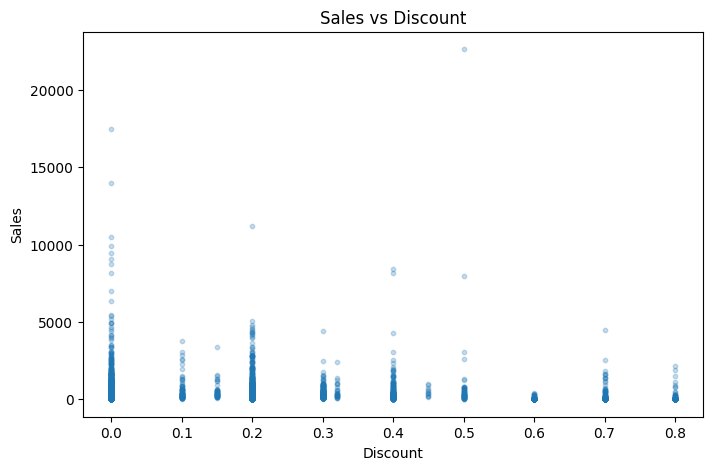

Slope / coefficient: -126.7518
Intercept: 245.5065


In [6]:
X_simple = df[[DISCOUNT_COL]].copy()
y = df[TARGET_COL].copy()

simple_data = pd.concat([X_simple, y], axis=1).dropna()
X_simple = simple_data[[DISCOUNT_COL]]
y_simple = simple_data[TARGET_COL]

plt.figure(figsize=(8, 5))
plt.scatter(X_simple[DISCOUNT_COL], y_simple, alpha=0.25, s=10)
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.title('Sales vs Discount')
plt.show()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_s = simple_model.predict(X_test_s)

print(f"Slope / coefficient: {simple_model.coef_[0]:.4f}")
print(f"Intercept: {simple_model.intercept_:.4f}")

## Slide 10 — Multiple Linear Regression

**What we do now:**
- Use several features.
- Train the model.
- Make predictions.

**Forecasting caveat:** `Profit` may not be known before a sale. We use it here for class practice.


In [8]:
features = [c for c in [DISCOUNT_COL, QUANTITY_COL, PROFIT_COL] if c is not None]
X = df[features].copy()
y = df[TARGET_COL].copy()

model_data = pd.concat([X, y], axis=1).dropna()
X = model_data[features]
y = model_data[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred = multi_model.predict(X_test)

coef_df = pd.DataFrame({"Feature": features, "Coefficient": multi_model.coef_})
display(coef_df)
print("Intercept:", multi_model.intercept_)

# metrics_multi = evaluate_regression(y_test, y_pred, "Multiple LR")

,Feature,Coefficient
0,Discount,249.571780
1,Quantity,41.550264
2,Profit,1.561674


Intercept: -18.097131357548733


## Slide 11 — Coefficients

**What we do now:**
- Plot coefficients.
- Interpret signs carefully.
- Remember: magnitudes are not directly comparable if scales differ.


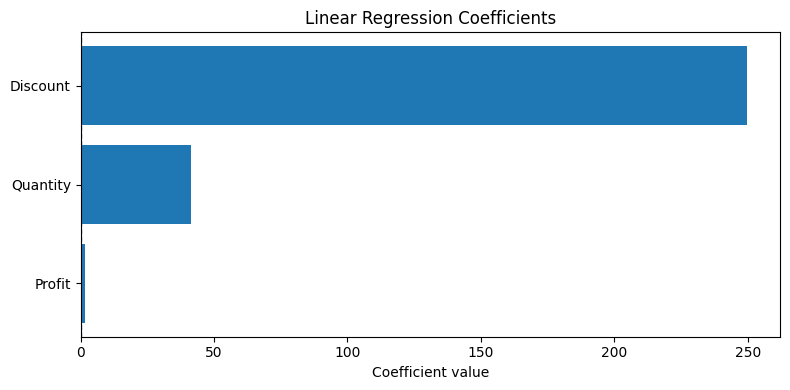

Discount: holding other selected features constant, +1 unit changes predicted Sales by 249.57.
Quantity: holding other selected features constant, +1 unit changes predicted Sales by 41.55.
Profit: holding other selected features constant, +1 unit changes predicted Sales by 1.56.


In [9]:
coef_df_sorted = coef_df.sort_values('Coefficient')
plt.figure(figsize=(8, 4))
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'])
plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel('Coefficient value')
plt.title('Linear Regression Coefficients')
plt.tight_layout()
plt.show()

for _, row in coef_df.iterrows():
    print(f"{row['Feature']}: holding other selected features constant, +1 unit changes predicted Sales by {row['Coefficient']:.2f}.")

## Slide 12 — Metrics

**What we do now:**
- Evaluate simple and multiple models.
- Compare MAE, MSE, RMSE, R².


In [10]:
def evaluate_regression(y_true, y_pred, model_name="Model"):
    """Return common regression metrics as a small dictionary."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R²:   {r2:.4f}")
    return {"Model": model_name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

In [11]:
metrics_simple = evaluate_regression(y_test_s, y_pred_s, "Simple LR: Discount only")
metrics_multi = evaluate_regression(y_test, y_pred, "Multiple LR")
comparison_so_far = pd.DataFrame([metrics_simple, metrics_multi])
display(comparison_so_far)


--- Simple LR: Discount only ---
MSE:  592714.18
RMSE: 769.88
MAE:  286.23
R²:   -0.0034
--- Multiple LR ---
MSE:  680377.46
RMSE: 824.85
MAE:  245.08
R²:   -0.1518


,Model,MSE,RMSE,MAE,R2
0,Simple LR: Discount only,592714.180878,769.879329,286.234796,-0.003411
1,Multiple LR,680377.456372,824.849960,245.075570,-0.151817


## Slide 13 — Residual Analysis

**What we do now:**
- Plot predicted vs actual.
- Plot residuals.
- Plot residual distribution.


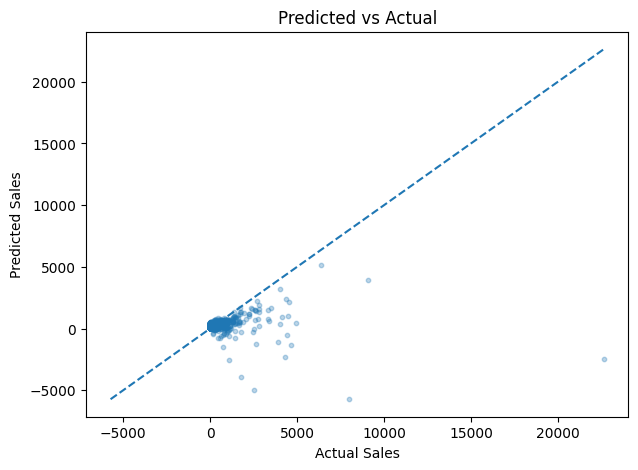

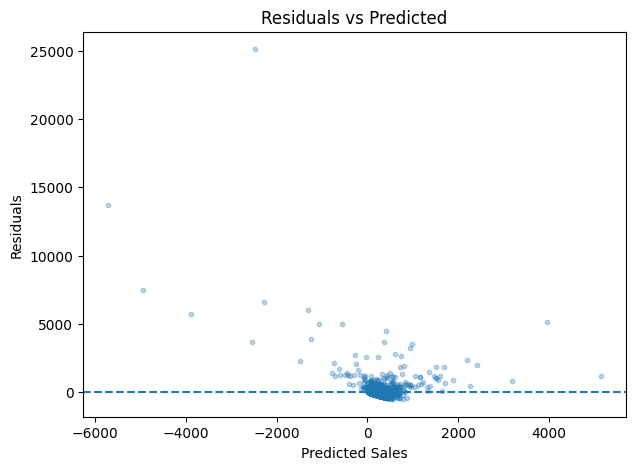

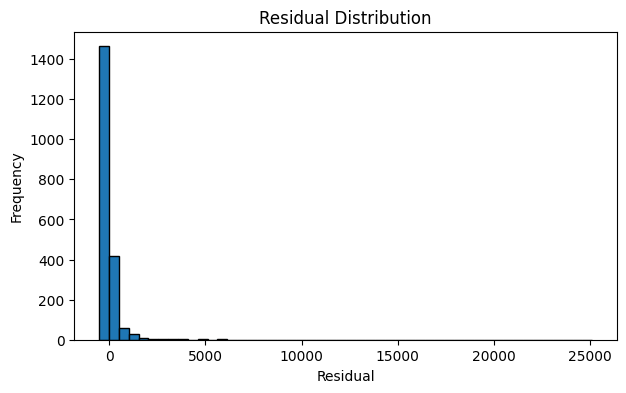

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual')
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

## Slides 14–16 — Polynomial Features + Overfitting

**What we do now:**
- Try degree 2 and degree 3.
- Compare metrics.
- Discuss underfit / good fit / overfit.


In [13]:
all_metrics = [metrics_simple, metrics_multi]

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)
    all_metrics.append(evaluate_regression(y_test, y_pred_poly, f"Polynomial degree {degree}"))

comparison = pd.DataFrame(all_metrics)
display(comparison.sort_values('RMSE'))

--- Polynomial degree 2 ---
MSE:  473873.85
RMSE: 688.38
MAE:  190.56
R²:   0.1978
--- Polynomial degree 3 ---
MSE:  467995.52
RMSE: 684.10
MAE:  177.83
R²:   0.2077


,Model,MSE,RMSE,MAE,R2
3,Polynomial degree 3,467995.515639,684.101978,177.834334,0.207726
2,Polynomial degree 2,473873.848878,688.384957,190.560721,0.197775
0,Simple LR: Discount only,592714.180878,769.879329,286.234796,-0.003411
1,Multiple LR,680377.456372,824.849960,245.075570,-0.151817


## Slides 17–19 — Gradient Descent + Learning Rate

**What we do now:**
- Run a toy GD demo.
- Watch loss go down.
- Optionally change `learning_rate`.

**Toy demo only:** this synthetic line makes learning visible. Connect it back to Superstore by saying: the real model also learned weights.


,epoch,weight,loss
0,0,0.242227,7.313112
1,1,0.464415,6.188171
2,2,0.668221,5.241664
3,3,0.855166,4.445289
4,4,1.026645,3.775233


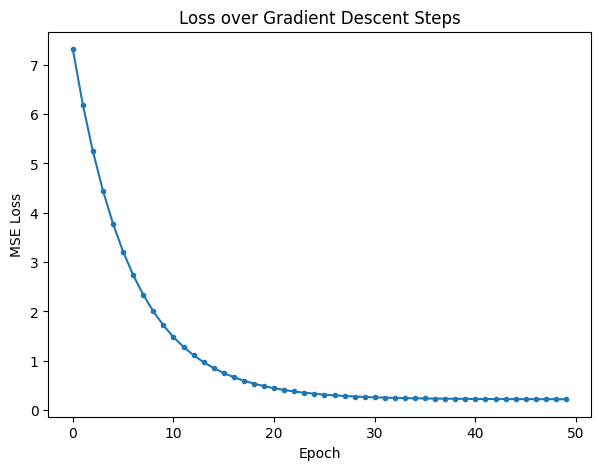

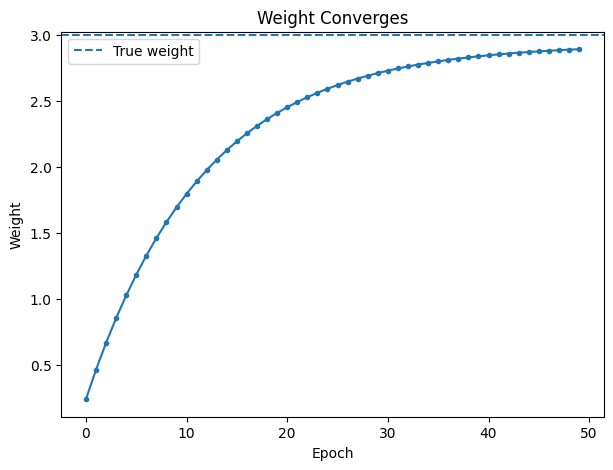

In [14]:
np.random.seed(42)
x_gd = np.random.randn(100)
y_gd = 3.0 * x_gd + np.random.randn(100) * 0.5

w = 0.0
learning_rate = 0.05
epochs = 50
history = []

for epoch in range(epochs):
    y_hat = w * x_gd
    loss = np.mean((y_gd - y_hat) ** 2)
    gradient = -2 * np.mean(x_gd * (y_gd - y_hat))
    w = w - learning_rate * gradient
    history.append({'epoch': epoch, 'weight': w, 'loss': loss})

history_df = pd.DataFrame(history)

display(history_df.head())

plt.figure(figsize=(7, 5))
plt.plot(history_df['epoch'], history_df['loss'], marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss over Gradient Descent Steps')
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_df['epoch'], history_df['weight'], marker='o', markersize=3)
plt.axhline(3.0, linestyle='--', label='True weight')
plt.xlabel('Epoch')
plt.ylabel('Weight')
plt.title('Weight Converges')
plt.legend()
plt.show()

## Slides 20–22 — Checkpoint + Workflow + Homework

Answer in a markdown cell:

1. What is the target column?
2. Which metrics did we use?
3. Which model performed best in the comparison table?
4. What does a coefficient mean?
5. Why can polynomial features overfit?

Save as: `M4C1_Level1_YourName.ipynb`.


### 1. What is the target comlumn?

  Target collumn - target is an example of our result we supposed to get, it is like a tower with given top part, and when tesing the top will not be given.

### 2. What metrics did we use?
  We have used 3 metrics collumns, Discount, Quantity, Profit

### 4. What does coefficient mean?
  Coefficient for Discount, Quantity, Profit represent the expected change in the targe variable Sales for a one unit increse in that specific feature assuming all other features stay sontant.

### 5. What are Polynomial Features?
  Polinomial Features is a type feature engineering in Machine learning used to define non linear relationship between variables by creating new features from existing ones



